In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import LinearFlow
from functools import partial


In [ ]:
linear = jax.jit(nnx.Linear(5096,5096, rngs=nnx.Rngs(0), precision = "BF16_BF16_F32", dtype=jnp.bfloat16))

In [4]:
linear2 = jax.jit(nnx.Linear(5096,5096, rngs=nnx.Rngs(0), precision="BF16_BF16_F32", dtype=jnp.bfloat16, dot_general = partial(jax.lax.dot_general, preferred_element_type=jnp.float32)))


In [5]:
linear3 = jax.jit(lambda x: linear(x).astype(jnp.float32))

In [6]:
linear4 = jax.jit(nnx.Linear(5096,5096, rngs=nnx.Rngs(0)))

In [46]:
linear5 = jax.jit(nnx.Linear(5096,5096, rngs=nnx.Rngs(0), precision = "BF16_BF16_BF16", dtype=jnp.bfloat16))

In [20]:
x = jnp.ones((1024,5096), dtype=jnp.float32) * 10

In [43]:
%%timeit -n 10_000
out = linear(x)
_ = out.block_until_ready()

369 μs ± 2.98 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [38]:
%%timeit -n 10_000
out2 = linear2(x)
_ = out2.block_until_ready()

370 μs ± 644 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [41]:
%%timeit -n 10_000
out3 = linear3(x)
_ = out3.block_until_ready()

388 μs ± 2.79 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [42]:
%%timeit -n 10_000
out4 = linear4(x)
_ = out4.block_until_ready()

683 μs ± 3.11 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [47]:
%%timeit -n 10_000
out4 = linear5(x)
_ = out4.block_until_ready()

XlaRuntimeError: UNIMPLEMENTED: Unsupported algorithm on the current device(s): ALG_DOT_BF16_BF16_BF16

In [21]:
out = linear(x)
out2 = linear2(x)
out3 = linear3(x)
out4 = linear4(x)

In [22]:
print(jnp.abs(out - out2).mean())

0.011075523


In [23]:
print(jnp.abs(out4-out2).mean())

0.013169803


In [24]:
print(jnp.abs(out4-out).mean())

0.017922048


In [19]:
print(jnp.abs(out-out3).mean())

0.0


In [ ]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [4]:

import scipy
def img_aug(x):
    xs_batch = x["image"]
    xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)
    
    # Normalize to [0, 1] and add small uniform noise for dequantization
    xs_batch = xs_batch.astype(np.float32) / 255.0
    xs_batch += np.random.uniform(0, 1/255, xs_batch.shape)
    # Move to [-1,1]
    xs_batch = 2*xs_batch - 1
    xs_batch = np.clip(xs_batch, -1.0, 1.0)
    return xs_batch[..., None] # Add channel dimension

In [5]:
from probjax.nn.io_util import DataLoader

loader = DataLoader(dataset["train"],batch_size=256, num_prefetch_host=32, num_prefetch_device=8, shard=False, host_transforms=img_aug, num_async_workers=4)

In [6]:
datastream = iter(loader)

In [7]:
%%timeit
y = next(datastream)
_ = y.block_until_ready()

50.8 μs ± 1.06 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


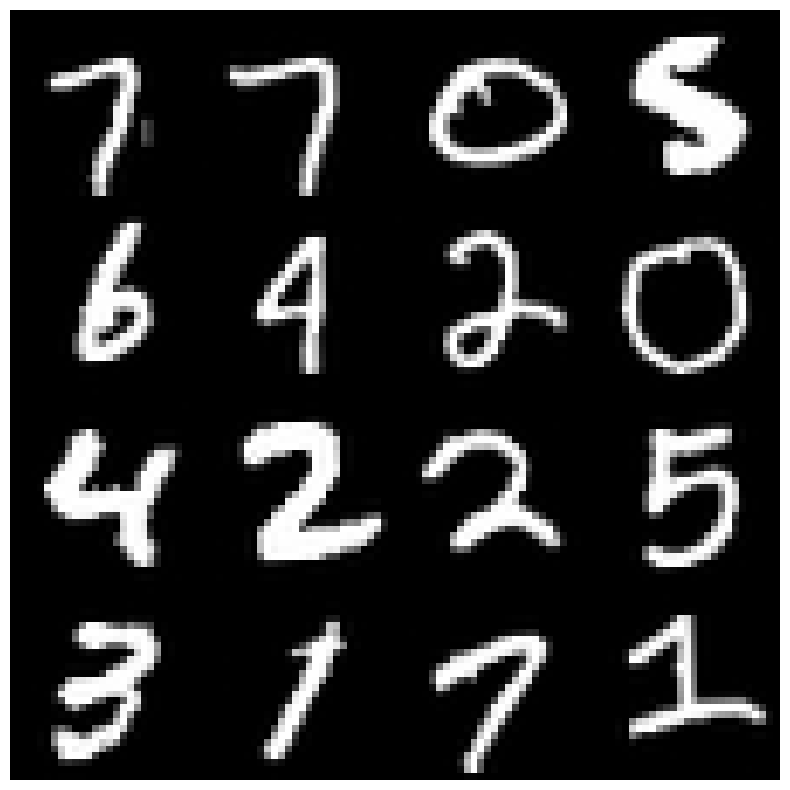

In [8]:
images = next(datastream)[:16,:,:,0]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [9]:
from probjax.nn.nets.unets import UNet, Conv, ConvTranspose, ResnetBlock, ResizeConv
from functools import partial
import time

In [10]:
xs = []
for i in range(5000):
    xs.append(next(datastream))
    time.sleep(0.001)
    

std1 = np.concatenate(xs, axis=0).std(0) + 0.01
mu1 = np.concatenate(xs, axis=0).mean(0)
del xs

In [11]:
shapes = [(16,16), (8,8), (4,4)]
conv_up_cls = [partial(ResizeConv, out_shape=shape, dtype=jnp.bfloat16, precision="BF16_BF16_F32") for shape in shapes]
conv_down_cls = [partial(ResizeConv, out_shape=shape,dtype=jnp.bfloat16, precision="BF16_BF16_F32") for shape in shapes]

In [77]:

class Denoiser(nnx.Module):
    def __init__(self, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,256, rngs=rngs, learnable=True)
        # Pass norm=nnx.GroupNorm instead of num_groups to UNet/ResnetBlock
        self.net = UNet(
            1,
            rngs=rngs,
            kernel_size=(3,3),
            strides=(1,1),
            kernel_size_resnet=(4,4),
            out_features=[128,256,256,512],
            context_features=256,
            use_attention=[False, False,True, True],
            resize_method="nearest",
            resnet_block_cls=partial(ResnetBlock, dtype=jnp.bfloat16, precision="BF16_BF16_F32", preferred_element_type=jnp.float32),
            conv_cls=partial(nnx.Conv, dtype=jnp.bfloat16, precision="BF16_BF16_F32"),
            conv_down_cls = conv_down_cls,
            conv_up_cls = conv_up_cls,
            #conv_down_cls=partial(nnx.Conv, dtype=jnp.bfloat16, precision="BF16_BF16_F32"),
            #conv_up_cls=partial(nnx.ConvTranspose, dtype=jnp.bfloat16, precision="BF16_BF16_F32"),
            preferred_element_dtype=jnp.float32,
        )

    def __call__(self, t, x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed, *args, **kwargs).astype(jnp.float32)
        return out

net = Denoiser(nnx.Rngs(1))
model = LinearFlow(net, std1=std1, mu1=mu1)
params = nnx.state(model, nnx.Param)

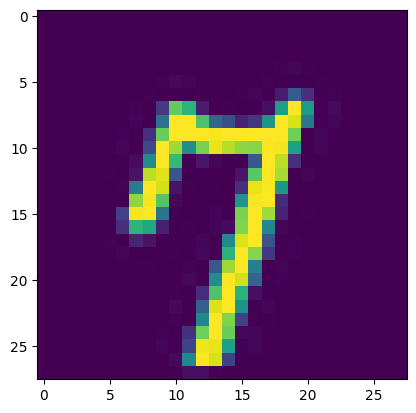

Down: (256, 28, 28, 128)
Down: (256, 16, 16, 256)
Down: (256, 8, 8, 256)
Mid: (256, 4, 4, 512)
Up: (256, 4, 4, 256)
Up: (256, 8, 8, 256)
Up: (256, 16, 16, 128)


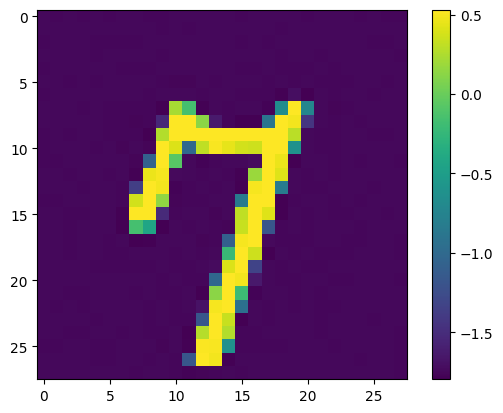

In [78]:
x = next(datastream)
plt.imshow(x[0])
plt.show()
plt.imshow(net(jnp.ones((256,1,1,1)),x,verbose=True)[0])
plt.colorbar()

In [72]:
#%%timeit
#jax.jit(net)(jnp.ones((256,1,1,1)), next(datastream))

In [15]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_util.tree_leaves(params)))

Number of parameters:  57700449


In [16]:
def loss_fn(params, x, rng):
    nnx.update(model, params)
    return model.loss(rng, x, axis=(-3,-2,-1), adaptive_weight_p=0.8, adaptive_weight_eps=1e-2)


In [17]:
loss_fn(params, next(datastream), jax.random.key(0))

Array(4.81, dtype=float32)

In [18]:
from functools import partial
import optax


opt = optax.chain(optax.adaptive_grad_clip(10.), optax.adamw(5e-4))
opt_state = opt.init(params)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    params, opt_state, losses = update(params, opt_state, xs, rng)
    return params, opt_state, jnp.mean(losses)


In [19]:
key = jax.random.key(2)

In [20]:
params, opt_state, loss = train_step(params, opt_state, next(datastream), key)

2025-08-13 15:42:01.885131: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (bf16[256,29,29,128]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,28,28,128]{3,2,1,0}, bf16[128,4,4,128]{3,2,1,0}), window={size=4x4 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-08-13 15:42:01.984901: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.099934704s
Trying algorithm eng0{} for conv (bf16[256,29,29,128]{3,2,1,0}, u8[0]{0}) custom-call(bf16[256,28,28,128]{3,2,1,0}, bf16[128,4,4,128]{3,2,1,0}), window={size=4x4 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queu

In [21]:
loss

Array(4.816, dtype=float32)

In [36]:
# Example training iteration
for i in range(100):
    l = 0.
    for j in range(200): 
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datastream)
        params, opt_state, loss = train_step(params, opt_state, xs, key_loss)
        l += loss
    print(l/200)

2.547345
2.5465274
2.5503595
2.5451922
2.5481272
2.5461433
2.5444646
2.551056
2.5459175
2.5491657
2.5468488
2.5474312
2.5470903
2.550438
2.550121
2.5488179
2.5533888
2.549495
2.5440001
2.5513945
2.5456867
2.5528324
2.5482857
2.5504532
2.5470216
2.5500953
2.5489097
2.548996
2.5511923
2.5462348
2.5486047
2.5491765
2.55009
2.5516806
2.5515654
2.5589714
2.549276
2.5516884
2.5530024
2.5508025
2.5595148
2.5627425
2.5538614
2.5525153
2.5545044
2.5561092
2.5507455
2.551012
2.5513859
2.5575137
18.301603
2.640422
2.5824304
2.5698233
2.564324
2.562013
2.5565171
2.5534604
2.556942
2.5563574
2.5521438
2.5496085
2.552192
2.551308
2.5502431
2.5481813
2.5446432
2.545137
2.5502756
2.54752
2.5467906
2.5453904
2.541612
2.5459433
2.5416276
2.540632
2.5466137
2.544246
2.5490973
2.54336
2.5424514
2.5439954
2.5490727
2.5420716
2.544172
2.5441852
2.5437806
2.5422714
2.545495
2.5435195
2.545897
2.549355
2.5428977
2.545797
2.5462723
2.545732
2.5470269
2.54392
2.5494046
2.5485396


In [37]:
nnx.update(model, params)

In [38]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (28,28,1,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(100) 

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x) 
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")[-1]



In [39]:
keys = jax.random.split(jax.random.key(0), (16,))

In [40]:
xs = jax.vmap(sample)(keys)

In [41]:
xs.min(),xs.max()

(Array(-1.217, dtype=float32), Array(1.426, dtype=float32))

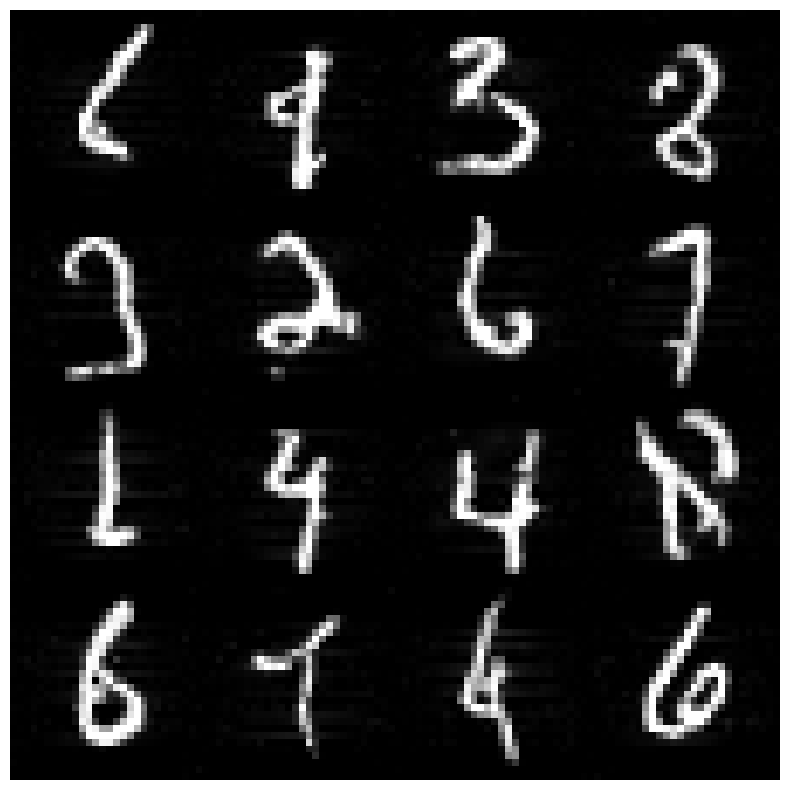

In [42]:
import matplotlib.pyplot as plt

img = xs.reshape(4, 4, 28, 28).transpose(0, 2, 1, 3).reshape(4*28, 4*28)
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
plt.axis('off')
plt.show()